### IMPORT LIBRARIES

In [76]:

import warnings
warnings.filterwarnings("ignore")

# Core
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    auc,
    f1_score,
    precision_score,
    recall_score
)

# Imbalanced Learning
from imblearn.over_sampling import SMOTE

# XGBoost
from xgboost import XGBClassifier

# Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

# Save Models
import joblib

### Load Dataset

In [77]:
df=pd.read_csv(r'C:\Users\anupa\Desktop\Python Learning\Fraud\creditcard.csv', low_memory=False)
print("="*60)
print("DATASET SHAPE")
print("="*60)
print(df.shape)


DATASET SHAPE
(284807, 31)


### BASIC DATA ANALYSIS

In [78]:

print("\nFIRST 5 ROWS\n")
print(df.head())

print("\nINFO\n")
print(df.info())

print("\nDESCRIPTION\n")
print(df.describe())

print("\nMISSING VALUES\n")
print(df.isnull().sum())

print("\nCLASS DISTRIBUTION\n")
print(df["Class"].value_counts())



FIRST 5 ROWS

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26      

### Visualize imbalance

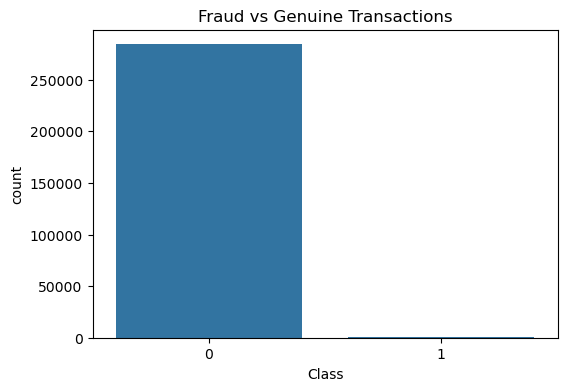

In [79]:

plt.figure(figsize=(6,4))

sns.countplot(x="Class", data=df)

plt.title("Fraud vs Genuine Transactions")

plt.show()

### Split Features and Target

In [80]:
X = df.drop("Class", axis=1)
y = df["Class"]



### Train-test split

In [81]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("\nTRAIN SHAPE:", X_train.shape)
print("TEST SHAPE:", X_test.shape)


TRAIN SHAPE: (227845, 30)
TEST SHAPE: (56962, 30)


### FEATURE SCALING

In [82]:
scaler = StandardScaler()

# Scale Amount and Time AFTER split
X_train[['Amount', 'Time']] = scaler.fit_transform(
    X_train[['Amount', 'Time']]
)

X_test[['Amount', 'Time']] = scaler.transform(
    X_test[['Amount', 'Time']]
)

### Handle Imbalanced Data Using SMOTE

In [83]:
#Fraud datasets are highly imbalanced.
#SMOTE generates synthetic minority class examples.
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("\nBEFORE SMOTE")
print(y_train.value_counts())

print("\nAFTER SMOTE")
print(y_train_smote.value_counts())




BEFORE SMOTE
Class
0    227451
1       394
Name: count, dtype: int64

AFTER SMOTE
Class
0    227451
1    227451
Name: count, dtype: int64


### Train Logistic Regression Model

In [84]:
print("\n" + "="*60)
print("LOGISTIC REGRESSION")
print("="*60)

# ------------------------------------------------------------
# Train Model
# ------------------------------------------------------------

lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_model.fit(
    X_train_smote,
    y_train_smote
)



LOGISTIC REGRESSION


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


### Predict Probabilities

In [85]:
y_prob_lr = lr_model.predict_proba(X_test)[:, 1]

### Precision Recall Curve


In [86]:
precision_lr, recall_lr, thresholds_lr = precision_recall_curve(
    y_test,
    y_prob_lr
)


### F1 Score for Every Threshold

In [87]:
f1_scores_lr = (
    2 * precision_lr[:-1] * recall_lr[:-1]
) / (
    precision_lr[:-1] + recall_lr[:-1] + 1e-10
)

### Best Threshold

In [88]:
best_idx_lr = np.argmax(f1_scores_lr)

best_threshold_lr = thresholds_lr[best_idx_lr]

print("\nBest Threshold:", best_threshold_lr)



Best Threshold: 0.9999999906914586


### Final Predictions

In [89]:
y_pred_lr = (
    y_prob_lr >= best_threshold_lr
).astype(int)

### Confusion Matrix


CONFUSION MATRIX

[[56848    16]
 [   18    80]]


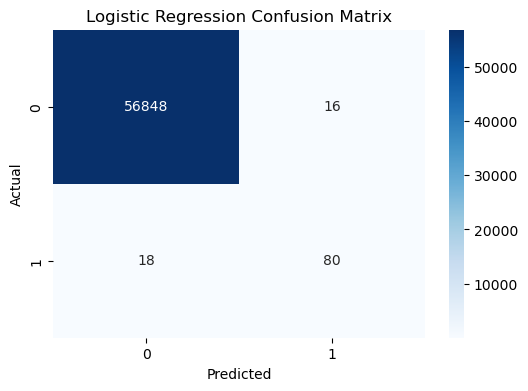

In [90]:
print("\nCONFUSION MATRIX\n")

cm_lr = confusion_matrix(y_test, y_pred_lr)

print(cm_lr)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Logistic Regression Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()


### Classification Report

In [91]:
print("\nCLASSIFICATION REPORT\n")

print(classification_report(y_test, y_pred_lr))

print(
    "Precision:",
    precision_score(y_test, y_pred_lr)
)

print(
    "Recall:",
    recall_score(y_test, y_pred_lr)
)

print(
    "F1 Score:",
    f1_score(y_test, y_pred_lr)
)

print(
    "ROC-AUC:",
    roc_auc_score(y_test, y_prob_lr)
)


CLASSIFICATION REPORT

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.82      0.82        98

    accuracy                           1.00     56962
   macro avg       0.92      0.91      0.91     56962
weighted avg       1.00      1.00      1.00     56962

Precision: 0.8333333333333334
Recall: 0.8163265306122449
F1 Score: 0.8247422680412371
ROC-AUC: 0.9698631105509169


###  ROC CURVE

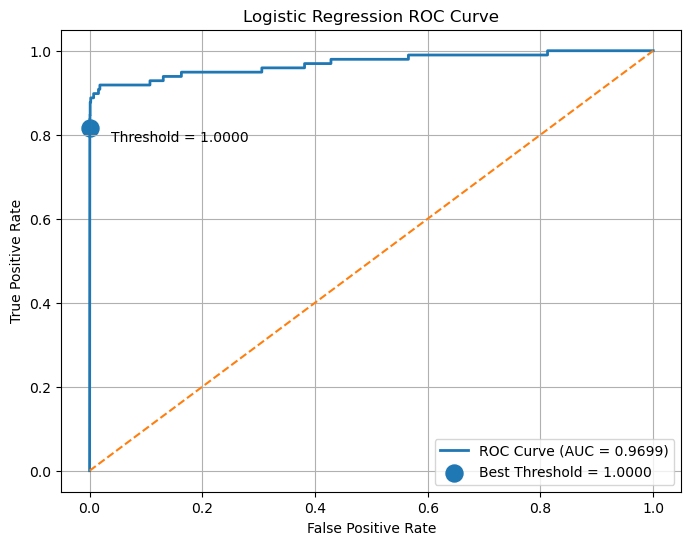

In [92]:
# ============================================================
# ROC CURVE WITH BEST THRESHOLD
# ============================================================

# ROC values
fpr_lr, tpr_lr, roc_thresholds_lr = roc_curve(
    y_test,
    y_prob_lr
)

# ROC-AUC Score
roc_auc_lr = roc_auc_score(
    y_test,
    y_prob_lr
)

# ------------------------------------------------------------
# Find ROC Point Closest to Best Threshold
# ------------------------------------------------------------

roc_best_idx = np.argmin(
    np.abs(roc_thresholds_lr - best_threshold_lr)
)

best_fpr = fpr_lr[roc_best_idx]
best_tpr = tpr_lr[roc_best_idx]

# ------------------------------------------------------------
# Plot ROC Curve
# ------------------------------------------------------------

plt.figure(figsize=(8,6))

# ROC Curve
plt.plot(
    fpr_lr,
    tpr_lr,
    linewidth=2,
    label=f"ROC Curve (AUC = {roc_auc_lr:.4f})"
)

# Random Guess Line
plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

# ------------------------------------------------------------
# Best Threshold Point
# ------------------------------------------------------------

plt.scatter(
    best_fpr,
    best_tpr,
    s=150,
    marker='o',
    label=f"Best Threshold = {best_threshold_lr:.4f}"
)

# ------------------------------------------------------------
# Annotate Threshold
# ------------------------------------------------------------

plt.annotate(
    f"Threshold = {best_threshold_lr:.4f}",
    (best_fpr, best_tpr),
    textcoords="offset points",
    xytext=(15,-10),
    fontsize=10
)

# ------------------------------------------------------------
# Labels
# ------------------------------------------------------------

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("Logistic Regression ROC Curve")

plt.legend()

plt.grid(True)

plt.show()

### Precision-Recall Curve

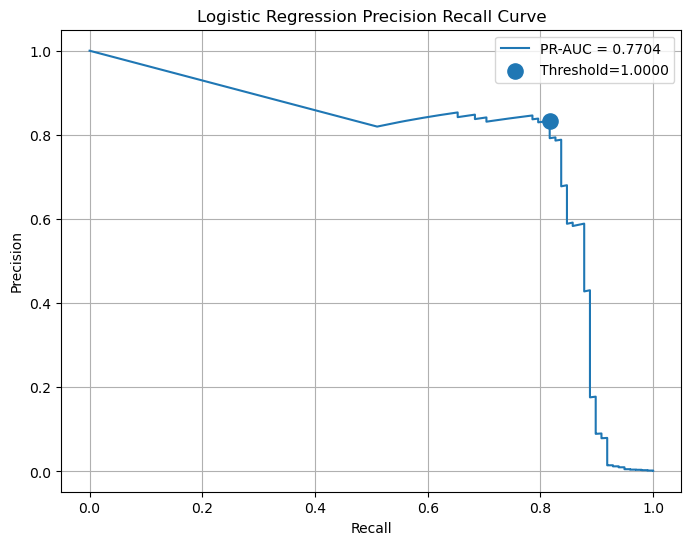

In [93]:
pr_auc_lr = auc(
    recall_lr,
    precision_lr
)

plt.figure(figsize=(8,6))

plt.plot(
    recall_lr,
    precision_lr,
    label=f"PR-AUC = {pr_auc_lr:.4f}"
)

plt.scatter(
    recall_lr[best_idx_lr],
    precision_lr[best_idx_lr],
    s=120,
    label=f"Threshold={best_threshold_lr:.4f}"
)

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.title("Logistic Regression Precision Recall Curve")

plt.legend()

plt.grid(True)

plt.show()

### Train Random Forest Model

In [94]:
print("\n" + "="*60)
print("RANDOM FOREST")
print("="*60)

# ------------------------------------------------------------
# Train Model
# ------------------------------------------------------------

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

rf_model.fit(
    X_train_smote,
    y_train_smote
)


RANDOM FOREST


,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### Predict Probabilities

In [95]:
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

 ### Precision Recall Curve

In [96]:
precision_rf, recall_rf, thresholds_rf = precision_recall_curve(
    y_test,
    y_prob_rf
)

### F1 Scores

In [97]:
f1_scores_rf = (
    2 * precision_rf[:-1] * recall_rf[:-1]
) / (
    precision_rf[:-1] + recall_rf[:-1] + 1e-10
)


### Best Threshold

In [98]:
best_idx_rf = np.argmax(f1_scores_rf)

best_threshold_rf = thresholds_rf[best_idx_rf]

print("\nBest Threshold:", best_threshold_rf)



Best Threshold: 0.775


### Final Predictions

In [99]:
y_pred_rf = (
    y_prob_rf >= best_threshold_rf
).astype(int)


### Evaluation


CONFUSION MATRIX

[[56861     3]
 [   22    76]]


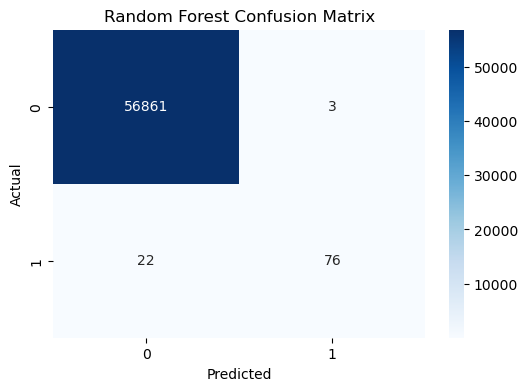


CLASSIFICATION REPORT

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.96      0.78      0.86        98

    accuracy                           1.00     56962
   macro avg       0.98      0.89      0.93     56962
weighted avg       1.00      1.00      1.00     56962

Precision: 0.9620253164556962
Recall: 0.7755102040816326
F1 Score: 0.8587570621468926
ROC-AUC: 0.9753984264640014


In [100]:
print("\nCONFUSION MATRIX\n")

cm_rf = confusion_matrix(
    y_test,
    y_pred_rf
)

print(cm_rf)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Random Forest Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

print("\nCLASSIFICATION REPORT\n")

print(classification_report(
    y_test,
    y_pred_rf
))

print(
    "Precision:",
    precision_score(y_test, y_pred_rf)
)

print(
    "Recall:",
    recall_score(y_test, y_pred_rf)
)

print(
    "F1 Score:",
    f1_score(y_test, y_pred_rf)
)

print(
    "ROC-AUC:",
    roc_auc_score(y_test, y_prob_rf)
)


### Feature Importance


TOP FEATURES

   Feature  Importance
14     V14    0.183722
10     V10    0.111426
4       V4    0.107697
12     V12    0.096527
17     V17    0.086023
11     V11    0.062094
3       V3    0.058454
16     V16    0.053111
2       V2    0.031257
7       V7    0.023408


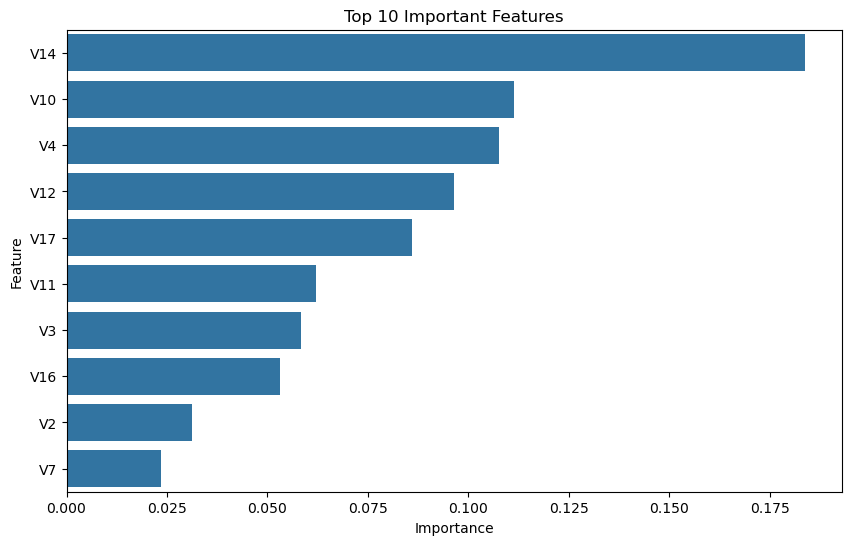

In [101]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print("\nTOP FEATURES\n")

print(importance.head(10))

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance.head(10)
)

plt.title("Top 10 Important Features")

plt.show()


### Save the Model

In [102]:
joblib.dump(rf_model, 'fraud_detection_rf.pkl')

['fraud_detection_rf.pkl']

###  XGBOOST MODEL

In [103]:
print("\n" + "="*60)
print("XGBOOST")
print("="*60)

# ------------------------------------------------------------
# Class Imbalance Weight
# ------------------------------------------------------------

scale_pos_weight = (
    len(y_train[y_train == 0]) /
    len(y_train[y_train == 1])
)

# ------------------------------------------------------------
# Train Model
# ------------------------------------------------------------

xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)

xgb_model.fit(
    X_train,
    y_train
)


XGBOOST


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


### Predict Probabilities

In [104]:
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

### Precision Recall Curve

In [105]:
precision_xgb, recall_xgb, thresholds_xgb = precision_recall_curve(
    y_test,
    y_prob_xgb
)

### F1 Scores

In [106]:
f1_scores_xgb = (
    2 * precision_xgb[:-1] * recall_xgb[:-1]
) / (
    precision_xgb[:-1] + recall_xgb[:-1] + 1e-10
)


### Best Threshold

In [107]:

best_idx_xgb = np.argmax(f1_scores_xgb)

best_threshold_xgb = thresholds_xgb[best_idx_xgb]

print("\nBest Threshold:", best_threshold_xgb)


Best Threshold: 0.93744224


### Final Predictions

In [108]:
y_pred_xgb = (
    y_prob_xgb >= best_threshold_xgb
).astype(int)


### Evaluation


CONFUSION MATRIX

[[56857     7]
 [   17    81]]


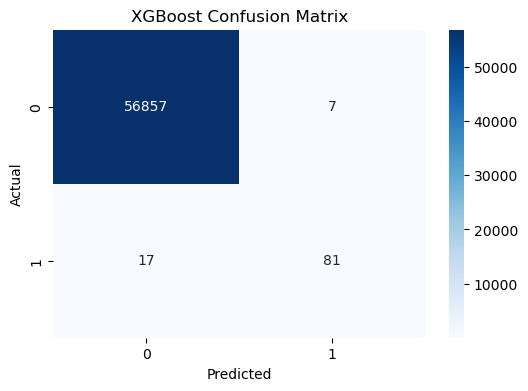


CLASSIFICATION REPORT

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.92      0.83      0.87        98

    accuracy                           1.00     56962
   macro avg       0.96      0.91      0.94     56962
weighted avg       1.00      1.00      1.00     56962

Precision: 0.9204545454545454
Recall: 0.826530612244898
F1 Score: 0.8709677419354839
ROC-AUC: 0.9829015596109011


In [109]:
print("\nCONFUSION MATRIX\n")

cm_xgb = confusion_matrix(
    y_test,
    y_pred_xgb
)

print(cm_xgb)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_xgb,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("XGBoost Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

print("\nCLASSIFICATION REPORT\n")

print(classification_report(
    y_test,
    y_pred_xgb
))

print(
    "Precision:",
    precision_score(y_test, y_pred_xgb)
)

print(
    "Recall:",
    recall_score(y_test, y_pred_xgb)
)

print(
    "F1 Score:",
    f1_score(y_test, y_pred_xgb)
)

print(
    "ROC-AUC:",
    roc_auc_score(y_test, y_prob_xgb)
)

### Feed Forward Neural Network 

### Build Feed Forward Neural Network
Architecture:
Input Layer/
Hidden Layer 1/
Hidden Layer 2/
Output Layer

In [110]:

print("\n" + "="*60)
print("FEED FORWARD NEURAL NETWORK")
print("="*60)

# ------------------------------------------------------------
# Class Weights
# ------------------------------------------------------------

neg = len(y_train[y_train == 0])
pos = len(y_train[y_train == 1])

weight_for_0 = 1.0
weight_for_1 = neg / pos

class_weight = {
    0: weight_for_0,
    1: weight_for_1
}

# ------------------------------------------------------------
# Build Model
# ------------------------------------------------------------

ffnn_model = Sequential()

ffnn_model.add(
    Dense(
        64,
        activation='relu',
        input_dim=X_train.shape[1]
    )
)

ffnn_model.add(Dropout(0.3))

ffnn_model.add(Dense(32, activation='relu'))

ffnn_model.add(Dropout(0.3))

ffnn_model.add(Dense(16, activation='relu'))

ffnn_model.add(Dense(1, activation='sigmoid'))



FEED FORWARD NEURAL NETWORK


### Compile the Model

In [111]:
ffnn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.AUC(name='auc')
    ]
)

### Early Stopping

In [112]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)


### Train the Neural Network

In [113]:
history = ffnn_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=256,
    class_weight=class_weight,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/30
713/713 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - auc: 0.9254 - loss: 0.6342 - precision: 0.0125 - recall: 0.8264 - val_auc: 0.9810 - val_loss: 0.1203 - val_precision: 0.0690 - val_recall: 0.9157
Epoch 2/30
713/713 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - auc: 0.9699 - loss: 0.3980 - precision: 0.0349 - recall: 0.9035 - val_auc: 0.9847 - val_loss: 0.0667 - val_precision: 0.1195 - val_recall: 0.9157
Epoch 3/30
713/713 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - auc: 0.9769 - loss: 0.3397 - precision: 0.0483 - recall: 0.9164 - val_auc: 0.9890 - val_loss: 0.0850 - val_precision: 0.0747 - val_recall: 0.9157
Epoch 4/30
713/713 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - auc: 0.9805 - loss: 0.3108 - precision: 0.0525 - recall: 0.9164 - val_auc: 0.9900 - val_loss: 0.0664 - val_precision: 0.0959 - val_recall: 0.8916
Epoch 5/30
713/713 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - auc: 0.9886 - loss: 0.2499 - precision: 0.0561 - recall: 0.9293 - val_auc: 0.9898 - val_loss: 0.0504 - val_precision: 0.1192 - val_recall: 0.9036


### Predict Probabilities

In [114]:

y_prob_nn = ffnn_model.predict(X_test).ravel()

1781/1781 ━━━━━━━━━━━━━━━━━━━━ 2s 881us/step


### Precision Recall Curve

In [115]:
precision_nn, recall_nn, thresholds_nn = precision_recall_curve(
    y_test,
    y_prob_nn
)


### F1 Scores

In [116]:
f1_scores_nn = (
    2 * precision_nn[:-1] * recall_nn[:-1]
) / (
    precision_nn[:-1] + recall_nn[:-1] + 1e-10
)

### Best Threshold

In [117]:
best_idx_nn = np.argmax(f1_scores_nn)

best_threshold_nn = thresholds_nn[best_idx_nn]

print("\nBest Threshold:", best_threshold_nn)



Best Threshold: 0.98932815


### Final Predictions

In [118]:
y_pred_nn = (
    y_prob_nn >= best_threshold_nn
).astype(int)


### Evaluate FFNN Model


CONFUSION MATRIX

[[56845    19]
 [   16    82]]


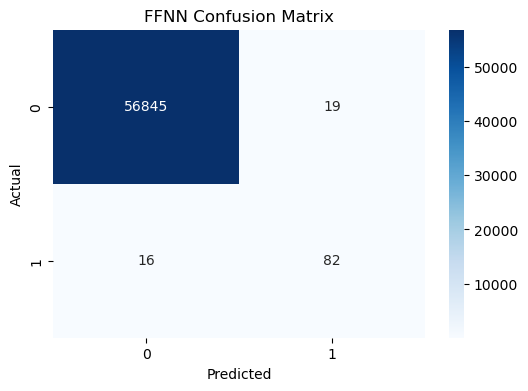


CLASSIFICATION REPORT

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.81      0.84      0.82        98

    accuracy                           1.00     56962
   macro avg       0.91      0.92      0.91     56962
weighted avg       1.00      1.00      1.00     56962

Precision: 0.8118811881188119
Recall: 0.8367346938775511
F1 Score: 0.8241206030150754
ROC-AUC: 0.9836590956725966


In [119]:
print("\nCONFUSION MATRIX\n")

cm_nn = confusion_matrix(
    y_test,
    y_pred_nn
)

print(cm_nn)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_nn,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("FFNN Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

print("\nCLASSIFICATION REPORT\n")

print(classification_report(
    y_test,
    y_pred_nn
))

print(
    "Precision:",
    precision_score(y_test, y_pred_nn)
)

print(
    "Recall:",
    recall_score(y_test, y_pred_nn)
)

print(
    "F1 Score:",
    f1_score(y_test, y_pred_nn)
)

print(
    "ROC-AUC:",
    roc_auc_score(y_test, y_prob_nn)
)


### TRAINING CURVES

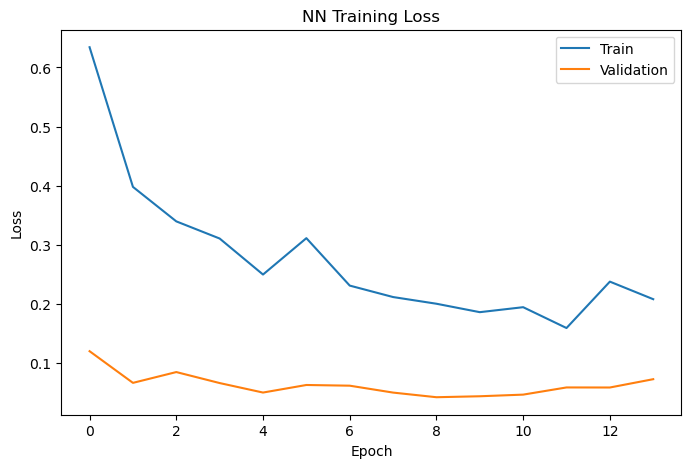

In [120]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'])

plt.plot(history.history['val_loss'])

plt.title("NN Training Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend(['Train', 'Validation'])

plt.show()


### Save Neural Network Model

In [121]:
ffnn_model.save("fraud_detection_ffnn.h5")

### Autoencoder 

#### Input layer

In [122]:
print("\n" + "="*60)
print("AUTOENCODER")
print("="*60)

# ------------------------------------------------------------
# Train ONLY on Normal Transactions
# ------------------------------------------------------------

X_train_normal = X_train[
    y_train == 0
]

input_dim = X_train.shape[1]

input_layer = Input(shape=(input_dim,))



AUTOENCODER


#### Encoder

In [123]:
encoder = Dense(
    16,
    activation='relu'
)(input_layer)

encoder = Dense(
    8,
    activation='relu'
)(encoder)



#### Decoder

In [124]:
decoder = Dense(
    16,
    activation='relu'
)(encoder)

decoder = Dense(
    input_dim,
    activation='linear'
)(decoder)


####   Build Model

In [125]:

autoencoder = Model(
    inputs=input_layer,
    outputs=decoder
)

####  Compile Model

In [126]:
autoencoder.compile(
    optimizer='adam',
    loss='mse'
)

#### Train Model

In [127]:
history_auto = autoencoder.fit(
    X_train_normal,
    X_train_normal,
    epochs=20,
    batch_size=256,
    validation_split=0.2,
    verbose=1
)

Epoch 1/20
711/711 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.7237 - val_loss: 0.5128
Epoch 2/20
711/711 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.4663 - val_loss: 0.4368
Epoch 3/20
711/711 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.4269 - val_loss: 0.4169
Epoch 4/20
711/711 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.4078 - val_loss: 0.3989
Epoch 5/20
711/711 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.3923 - val_loss: 0.3856
Epoch 6/20
711/711 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.3797 - val_loss: 0.3733
Epoch 7/20
711/711 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3688 - val_loss: 0.3632
Epoch 8/20
711/711 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.3595 - val_loss: 0.3547
Epoch 9/20
711/711 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3516 - val_loss: 0.3480
Epoch 10/20
711/711 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.3442 - val_loss: 0.3395
Epoch 11/20
711/711 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.3390 - val_loss: 0.3361
Epoch 12/20
711/711 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

### Reconstruction

In [128]:
reconstructed = autoencoder.predict(
    X_test
)


1781/1781 ━━━━━━━━━━━━━━━━━━━━ 2s 989us/step


### Reconstruction Error

In [129]:
mse = np.mean(
    np.power(
        X_test - reconstructed,
        2
    ),
    axis=1
)

### Threshold

In [130]:
threshold_auto = np.percentile(
    mse,
    95
)

print("\nThreshold:", threshold_auto)



Threshold: 0.6647117706376563


### Final Predictions

In [131]:
y_pred_auto = (
    mse > threshold_auto
).astype(int)


### Evaluation


CONFUSION MATRIX

[[54102  2762]
 [   11    87]]


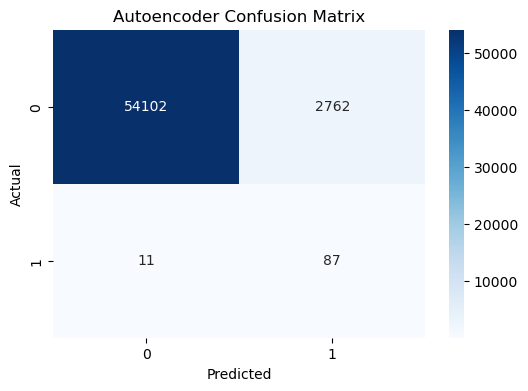


CLASSIFICATION REPORT

              precision    recall  f1-score   support

           0       1.00      0.95      0.98     56864
           1       0.03      0.89      0.06        98

    accuracy                           0.95     56962
   macro avg       0.52      0.92      0.52     56962
weighted avg       1.00      0.95      0.97     56962



In [132]:
print("\nCONFUSION MATRIX\n")

cm_auto = confusion_matrix(
    y_test,
    y_pred_auto
)

print(cm_auto)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_auto,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Autoencoder Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

print("\nCLASSIFICATION REPORT\n")

print(classification_report(
    y_test,
    y_pred_auto
))


### ENSEMBLE MODEL WITH DYNAMIC WEIGHTS

In [133]:
print("\n" + "="*60)
print("ENSEMBLE MODEL")
print("="*60)

# ============================================================
# STEP 1: CALCULATE PR-AUC FOR EACH MODEL
# PR-AUC is better for highly imbalanced fraud datasets
# ============================================================

# Logistic Regression PR-AUC
pr_auc_lr = auc(
    recall_lr,
    precision_lr
)

# Random Forest PR-AUC
pr_auc_rf = auc(
    recall_rf,
    precision_rf
)

# XGBoost PR-AUC
pr_auc_xgb = auc(
    recall_xgb,
    precision_xgb
)

# Neural Network PR-AUC
pr_auc_nn = auc(
    recall_nn,
    precision_nn
)

# ============================================================
# STEP 2: TOTAL SCORE
# ============================================================

total_pr_auc = (
    pr_auc_lr +
    pr_auc_rf +
    pr_auc_xgb +
    pr_auc_nn
)

# ============================================================
# STEP 3: DYNAMIC WEIGHTS
# ============================================================

w_lr = pr_auc_lr / total_pr_auc

w_rf = pr_auc_rf / total_pr_auc

w_xgb = pr_auc_xgb / total_pr_auc

w_nn = pr_auc_nn / total_pr_auc

# ============================================================
# DISPLAY DYNAMIC WEIGHTS
# ============================================================

print("\nDYNAMIC ENSEMBLE WEIGHTS\n")

print(f"Logistic Regression Weight : {w_lr:.4f}")

print(f"Random Forest Weight      : {w_rf:.4f}")

print(f"XGBoost Weight            : {w_xgb:.4f}")

print(f"Neural Network Weight     : {w_nn:.4f}")


ENSEMBLE MODEL

DYNAMIC ENSEMBLE WEIGHTS

Logistic Regression Weight : 0.2376
Random Forest Weight      : 0.2703
XGBoost Weight            : 0.2679
Neural Network Weight     : 0.2241


### WEIGHTED ENSEMBLE PROBABILITIES

In [134]:
ensemble_prob = (
    w_lr * y_prob_lr +
    w_rf * y_prob_rf +
    w_xgb * y_prob_xgb +
    w_nn * y_prob_nn
)

### PRECISION-RECALL CURVE

In [135]:

precision_en, recall_en, thresholds_en = precision_recall_curve(
    y_test,
    ensemble_prob
)


###  F1 SCORES FOR ALL THRESHOLDS

In [136]:
f1_scores_en = (
    2 * precision_en[:-1] * recall_en[:-1]
) / (
    precision_en[:-1] + recall_en[:-1] + 1e-10
)


###  BEST THRESHOLD

In [137]:

best_idx_en = np.argmax(
    f1_scores_en
)

best_threshold_en = thresholds_en[
    best_idx_en
]

print("\nBEST ENSEMBLE THRESHOLD:",
      best_threshold_en)




BEST ENSEMBLE THRESHOLD: 0.844006101811718


###  FINAL PREDICTIONS

In [138]:
y_pred_ensemble = (
    ensemble_prob >= best_threshold_en
).astype(int)


#### CONFUSION MATRIX


CONFUSION MATRIX

[[56857     7]
 [   17    81]]


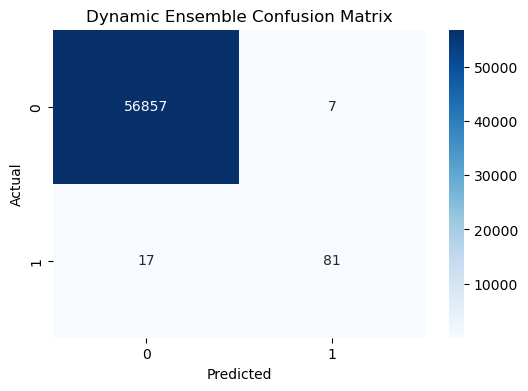

In [139]:
print("\nCONFUSION MATRIX\n")

cm_en = confusion_matrix(
    y_test,
    y_pred_ensemble
)

print(cm_en)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_en,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Dynamic Ensemble Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()


### CLASSIFICATION REPORT

In [140]:
print("\nCLASSIFICATION REPORT\n")

print(classification_report(
    y_test,
    y_pred_ensemble
))

print(
    "Precision:",
    precision_score(
        y_test,
        y_pred_ensemble
    )
)

print(
    "Recall:",
    recall_score(
        y_test,
        y_pred_ensemble
    )
)

print(
    "F1 Score:",
    f1_score(
        y_test,
        y_pred_ensemble
    )
)


CLASSIFICATION REPORT

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.92      0.83      0.87        98

    accuracy                           1.00     56962
   macro avg       0.96      0.91      0.94     56962
weighted avg       1.00      1.00      1.00     56962

Precision: 0.9204545454545454
Recall: 0.826530612244898
F1 Score: 0.8709677419354839


 ### ROC-AUC

In [141]:
ensemble_roc_auc = roc_auc_score(
    y_test,
    ensemble_prob
)

print(
    "ROC-AUC:",
    ensemble_roc_auc
)

ROC-AUC: 0.9776150471443502


### ROC CURVE WITH BEST THRESHOLD

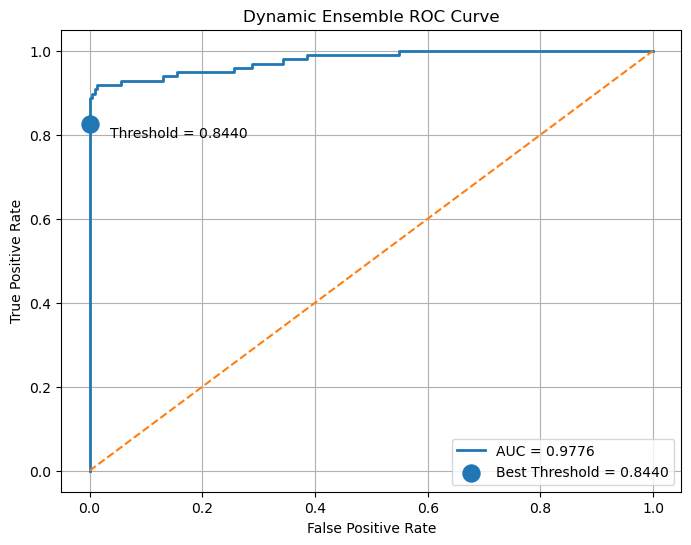

In [142]:
fpr_en, tpr_en, roc_thresholds_en = roc_curve(
    y_test,
    ensemble_prob
)

# Find Threshold Point on ROC Curve
roc_best_idx_en = np.argmin(
    np.abs(
        roc_thresholds_en -
        best_threshold_en
    )
)

best_fpr_en = fpr_en[roc_best_idx_en]

best_tpr_en = tpr_en[roc_best_idx_en]

# Plot ROC Curve
plt.figure(figsize=(8,6))

plt.plot(
    fpr_en,
    tpr_en,
    linewidth=2,
    label=f"AUC = {ensemble_roc_auc:.4f}"
)

# Random Guess Line
plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

# Best Threshold Point
plt.scatter(
    best_fpr_en,
    best_tpr_en,
    s=150,
    marker='o',
    label=f"Best Threshold = {best_threshold_en:.4f}"
)

# Annotate Threshold
plt.annotate(
    f"Threshold = {best_threshold_en:.4f}",
    (best_fpr_en, best_tpr_en),
    textcoords="offset points",
    xytext=(15,-10),
    fontsize=10
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("Dynamic Ensemble ROC Curve")

plt.legend()

plt.grid(True)

plt.show()


### PRECISION-RECALL CURVE

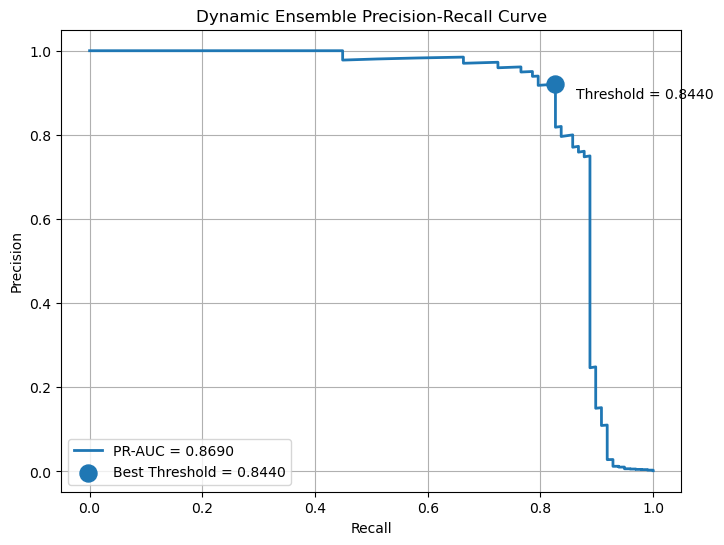

In [143]:
ensemble_pr_auc = auc(
    recall_en,
    precision_en
)

plt.figure(figsize=(8,6))

plt.plot(
    recall_en,
    precision_en,
    linewidth=2,
    label=f"PR-AUC = {ensemble_pr_auc:.4f}"
)

# Best Threshold Point
plt.scatter(
    recall_en[best_idx_en],
    precision_en[best_idx_en],
    s=150,
    marker='o',
    label=f"Best Threshold = {best_threshold_en:.4f}"
)

# Annotate Threshold
plt.annotate(
    f"Threshold = {best_threshold_en:.4f}",
    (
        recall_en[best_idx_en],
        precision_en[best_idx_en]
    ),
    textcoords="offset points",
    xytext=(15,-10),
    fontsize=10
)

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.title("Dynamic Ensemble Precision-Recall Curve")

plt.legend()

plt.grid(True)

plt.show()


### SAVE ENSEMBLE MODEL OUTPUTS

In [144]:
joblib.dump(
    {
        "weights": {
            "lr": w_lr,
            "rf": w_rf,
            "xgb": w_xgb,
            "nn": w_nn
        },
        "threshold": best_threshold_en
    },
    "dynamic_ensemble_config.pkl"
)

print("\nDynamic Ensemble Model Completed Successfully!")


Dynamic Ensemble Model Completed Successfully!
